In [1]:
import yfinance as yf
import pandas as pd

# Download SPY data
df = yf.download('SPY', start='2015-01-01', end='2024-12-31')
df = df[['Close']]
df.dropna(inplace=True)
df.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,SPY
Date,
2015-01-02,172.075211
2015-01-05,168.967621
2015-01-06,167.376144
2015-01-07,169.461807
2015-01-08,172.468933


In [2]:
def compute_rsi(series: pd.Series, lookback: int = 14) -> pd.Series:
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=lookback).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=lookback).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


In [3]:
df['RSI_14'] = compute_rsi(df['Close'], 14)
df['Signal'] = (df['RSI_14'] < 30).astype(int)  # 1 when RSI < 30, else 0
df.tail(10)


Price,Close,RSI_14,Signal
Ticker,SPY,,
Date,,,
2024-12-16,602.940796,64.735805,0
2024-12-17,600.456665,55.909083,0
2024-12-18,582.560974,36.646074,0
2024-12-19,582.382019,31.070054,0
2024-12-20,589.377075,39.384254,0
2024-12-23,592.906433,43.149017,0
2024-12-24,599.496582,46.097968,0
2024-12-26,599.536499,46.981846,0


In [4]:
def vectorized_long_only_backtest(df, hold_days=5):
    df = df.copy()
    df['Future_Return'] = df['Close'].pct_change(periods=hold_days).shift(-hold_days)
    df['Strategy_Return'] = df['Signal'].shift(1) * df['Future_Return']  # next day execution
    df.dropna(inplace=True)
    return df



In [5]:
backtest_result = vectorized_long_only_backtest(df)
backtest_result[['Close', 'RSI_14', 'Signal', 'Strategy_Return']].tail()


Price,Close,RSI_14,Signal,Strategy_Return
Ticker,SPY,,,
Date,,,,
2024-12-16,602.940796,64.735805,0,-0.0
2024-12-17,600.456665,55.909083,0,-0.0
2024-12-18,582.560974,36.646074,0,0.0
2024-12-19,582.382019,31.070054,0,0.0
2024-12-20,589.377075,39.384254,0,-0.0


Matplotlib is building the font cache; this may take a moment.


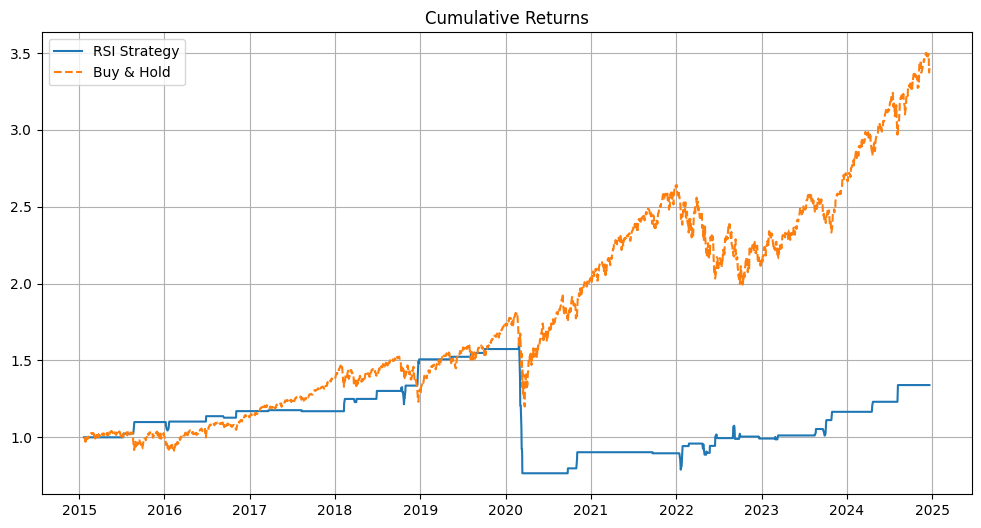

In [6]:
import matplotlib.pyplot as plt

backtest_result['Strategy_Cum'] = (1 + backtest_result['Strategy_Return']).cumprod()
backtest_result['BuyHold_Cum'] = (1 + backtest_result['Close'].pct_change()).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(backtest_result.index, backtest_result['Strategy_Cum'], label='RSI Strategy')
plt.plot(backtest_result.index, backtest_result['BuyHold_Cum'], label='Buy & Hold', linestyle='--')
plt.legend()
plt.title('Cumulative Returns')
plt.grid(True)
plt.show()


In [7]:
import numpy as np
import statsmodels.api as sm

def compute_all_metrics(df, return_col='Strategy_Return', benchmark_col='BuyHold_Return', risk_free_rate=0.01, freq=252):
    df = df.copy().dropna()
    returns = df[return_col]
    benchmark = df[benchmark_col]
    excess = returns - (risk_free_rate / freq)

    # Annualized Metrics
    total_return = (1 + returns).prod() - 1
    cagr = (1 + total_return) ** (freq / len(returns)) - 1
    std_return = returns.std() * np.sqrt(freq)
    variance = returns.var() * freq
    downside_std = returns[returns < 0].std() * np.sqrt(freq)

    # Sharpe & Sortino
    sharpe = excess.mean() / returns.std() * np.sqrt(freq)
    sortino = excess.mean() / downside_std if downside_std != 0 else np.nan

    # Alpha & Beta
    X = sm.add_constant(benchmark)
    model = sm.OLS(returns, X).fit()
    alpha = model.params[0] * freq
    beta = model.params[1]

    # Treynor & Information Ratio
    treynor = returns.mean() * freq / beta if beta != 0 else np.nan
    tracking_error = (returns - benchmark).std() * np.sqrt(freq)
    info_ratio = (returns - benchmark).mean() / (returns - benchmark).std() * np.sqrt(freq) if tracking_error != 0 else np.nan

    # Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative / rolling_max - 1
    max_drawdown = drawdown.min()

    # K-Ratio
    log_equity = np.log(cumulative)
    x = sm.add_constant(np.arange(len(log_equity)))
    y = log_equity.values
    k_model = sm.OLS(y, x).fit()
    slope = k_model.params[1]
    stderr = k_model.bse[1]
    k_ratio = slope / stderr if stderr != 0 else np.nan

    # Win rate, Avg win/loss, Profit-Loss ratio, Expectancy
    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / len(returns)
    avg_win = wins.mean()
    avg_loss = losses.mean()
    pl_ratio = avg_win / abs(avg_loss) if avg_loss != 0 else np.nan
    expectancy = returns.mean()

    return {
        'Total Return': f"{total_return:.2%}",
        'CAGR': f"{cagr:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Sortino Ratio': f"{sortino:.2f}",
        'Treynor Ratio': f"{treynor:.2f}",
        'Information Ratio': f"{info_ratio:.2f}",
        'Alpha (annual)': f"{alpha:.2%}",
        'Beta': f"{beta:.2f}",
        'K-Ratio': f"{k_ratio:.2f}",
        'Max Drawdown': f"{max_drawdown:.2%}",
        'Annual Variance': f"{variance:.4f}",
        'Annual Std Dev': f"{std_return:.2%}",
        'Win Rate': f"{win_rate:.2%}",
        'Avg Win': f"{avg_win:.2%}",
        'Avg Loss': f"{avg_loss:.2%}",
        'Profit/Loss Ratio': f"{pl_ratio:.2f}",
        'Expectancy per Trade': f"{expectancy:.4f}"
    }


In [8]:
backtest_result['BuyHold_Return'] = backtest_result['Close'].pct_change().shift(-1)


In [9]:
metrics = compute_all_metrics(backtest_result)
print("📊 All Performance Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")


📊 All Performance Metrics:
Total Return: 33.99%
CAGR: 3.00%
Sharpe Ratio: 0.22
Sortino Ratio: 0.00
Treynor Ratio: 0.31
Information Ratio: -0.51
Alpha (annual): 2.09%
Beta: 0.12
K-Ratio: -6.64
Max Drawdown: -52.54%
Annual Variance: 0.0162
Annual Std Dev: 12.72%
Win Rate: 2.89%
Avg Win: 2.35%
Avg Loss: -3.28%
Profit/Loss Ratio: 0.71
Expectancy per Trade: 0.0002


/var/folders/mb/yl5489tn58zfr770jy4nmqq00000gn/T/ipykernel_4614/2903351416.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0] * freq
/var/folders/mb/yl5489tn58zfr770jy4nmqq00000gn/T/ipykernel_4614/2903351416.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


In [10]:
results = []

rsi_thresholds = [25, 30, 35]
holding_periods = [3, 5, 10]

for rsi_thresh in rsi_thresholds:
    for hold_days in holding_periods:
        df = yf.download('SPY', start='2015-01-01', end='2024-12-31')[['Close']].dropna()
        df['RSI_14'] = compute_rsi(df['Close'], 14)
        df['Signal'] = (df['RSI_14'] < rsi_thresh).astype(int)
        df['BuyHold_Return'] = df['Close'].pct_change().shift(-1)

        backtest_df = vectorized_long_only_backtest(df, hold_days=hold_days)
        metrics = compute_all_metrics(backtest_df)

        row = {
            'RSI_Threshold': rsi_thresh,
            'Holding_Days': hold_days,
            **metrics
        }

        results.append(row)


[*********************100%***********************]  1 of 1 completed
/var/folders/mb/yl5489tn58zfr770jy4nmqq00000gn/T/ipykernel_4614/2903351416.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0] * freq
/var/folders/mb/yl5489tn58zfr770jy4nmqq00000gn/T/ipykernel_4614/2903351416.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
[*********************100%***********************]  1 of 1 completed
/var/folders/mb/yl5489tn58zfr770jy4nmqq00000gn/T/ipykernel_4614/2903351416.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future versio

In [11]:
import pandas as pd

metrics_df = pd.DataFrame(results)
metrics_df.sort_values(by='Sharpe Ratio', ascending=False, inplace=True)
metrics_df.reset_index(drop=True, inplace=True)


In [12]:
from ace_tools import display_dataframe_to_user
display_dataframe_to_user(name="Strategy Comparison Table", dataframe=metrics_df)

ModuleNotFoundError: No module named 'ace_tools'

In [13]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
display(metrics_df)


,RSI_Threshold,Holding_Days,Total Return,CAGR,Sharpe Ratio,Sortino Ratio,Treynor Ratio,Information Ratio,Alpha (annual),Beta,K-Ratio,Max Drawdown,Annual Variance,Annual Std Dev,Win Rate,Avg Win,Avg Loss,Profit/Loss Ratio,Expectancy per Trade
0,35,3,184.49%,11.12%,0.70,0.00,0.35,-0.13,7.03%,0.33,80.90,-54.24%,0.0237,15.38%,5.80%,2.25%,-2.14%,1.05,0.0005
1,35,5,231.36%,12.85%,0.69,0.00,0.49,-0.01,9.88%,0.29,29.24,-72.11%,0.0351,18.73%,6.53%,2.40%,-3.16%,0.76,0.0006
2,35,10,356.14%,16.59%,0.68,0.00,0.50,0.18,13.74%,0.38,30.54,-87.08%,0.0717,26.77%,6.34%,3.42%,-4.18%,0.82,0.0008
3,30,3,86.76%,6.50%,0.56,0.00,0.49,-0.40,4.87%,0.14,49.17,-34.81%,0.0108,10.37%,2.76%,2.33%,-2.16%,1.08,0.0003
4,25,3,58.48%,4.75%,0.47,0.00,0.43,-0.52,3.36%,0.12,47.68,-28.63%,0.0074,8.62%,1.52%,2.68%,-2.88%,0.93,0.0002
5,30,5,33.99%,3.00%,0.22,0.00,0.31,-0.51,2.09%,0.12,-6.58,-52.54%,0.0162,12.71%,2.88%,2.35%,-3.28%,0.71,0.0002
6,25,5,19.40%,1.81%,0.13,0.00,0.19,-0.64,0.65%,0.12,-9.87,-41.72%,0.0102,10.08%,1.68%,2.15%,-4.80%,0.45,0.0001
7,25,10,-20.52%,-2.30%,-0.13,-0.00,-0.11,-0.69,-2.35%,0.09,-45.40,-63.78%,0.0238,15.41%,1.44%,3.11%,-6.09%,0.51,-0.0000
8,30,10,-25.51%,-2.93%,-0.09,-0.00,-0.07,-0.60,-2.68%,0.13,-41.42,-79.17%,0.0390,19.76%,2.77%,3.13%,-5.22%,0.60,-0.0000


In [16]:
pivot_table = metrics_df.pivot(index='RSI_Threshold', columns='Holding_Days', values='Sortino Ratio')
pivot_table = pivot_table.astype(float)  # Ensure numeric for heatmap

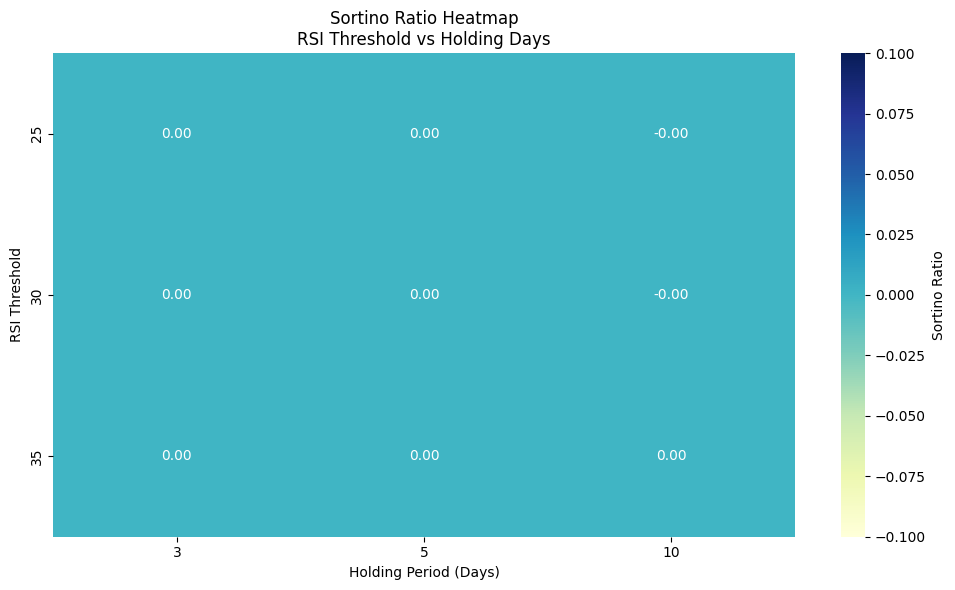

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Sortino Ratio'})
plt.title("Sortino Ratio Heatmap\nRSI Threshold vs Holding Days")
plt.ylabel("RSI Threshold")
plt.xlabel("Holding Period (Days)")
plt.tight_layout()
plt.show()
